# Mod-Cog RNN training (no viz)

Step 2 of the Branchpoint Mod-Cog demo: a leaky RNN trained on the GPU-resident trial bank from `make_trial_bank.py`.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

## Config

In [2]:
BANK_PATH = "modcog_bank.pt"
CKPT_PATH = "modcog_rnn.pt"
DEVICE = "cuda"
SEED = 0

N_HIDDEN = 256
TAU_MS = 200          # alpha = dt / tau; bank dt is 100 ms
SIGMA_REC = 0.05      # recurrent noise (training only)
ACTIVATION = "relu"   # "relu" | "tanh" | "softplus"
L2_RATE = 1e-4     # penalty on hidden activity
L2_WEIGHT = 1e-4   # penalty on recurrent weights

BATCH = 256
LR = 1e-3
N_STEPS = 20_000
GRAD_CLIP = 1.0
RESP_WEIGHT = 5.0     # upweight response steps; fixation dominates the labels

VAL_FRAC = 0.1
EVAL_EVERY = 500
EVAL_BATCH = 2048
PROBE_PER_TASK = 8

IGNORE_INDEX = -100
ACTIVATIONS = {"relu": F.relu, "tanh": torch.tanh, "softplus": F.softplus}

torch.manual_seed(SEED)

## Load bank onto the GPU

In [3]:
bank = torch.load(BANK_PATH, map_location=DEVICE)

obs = bank["obs"]              # (N, T, 33)
labels = bank["labels"]        # (N, T), padding = -100
lengths = bank["lengths"]      # (N,)
task_id = bank["task_id"]      # (N,)
family = bank["family"]        # (N,)
task_names = bank["task_names"]
family_names = bank["family_names"]

n_trials, t_max, ob_dim = obs.shape
n_tasks = len(task_names)
n_in = ob_dim + n_tasks
n_out = bank["n_ring"] + 1
alpha = bank["dt"] / TAU_MS
rule_eye = torch.eye(n_tasks, device=DEVICE)

print(f"{n_trials} trials, T={t_max}, n_in={n_in}, n_out={n_out}, alpha={alpha}")

20992 trials, T=67, n_in=115, n_out=17, alpha=0.25


## Train / val split and probe set

In [4]:
perm = torch.randperm(n_trials, device=DEVICE)
n_val = int(VAL_FRAC * n_trials)
val_idx = perm[:n_val]
train_idx = perm[n_val:]

# fixed probe set: first PROBE_PER_TASK val trials of each task (used for trajectory viz later)
val_tasks = task_id[val_idx]
order = torch.argsort(val_tasks, stable=True)
sorted_idx = val_idx[order]
sorted_tasks = val_tasks[order]
counts = torch.bincount(sorted_tasks, minlength=n_tasks)
starts = torch.cumsum(counts, 0) - counts
rank = torch.arange(len(sorted_idx), device=DEVICE) - starts[sorted_tasks]
probe_idx = sorted_idx[rank < PROBE_PER_TASK]

print(f"train {len(train_idx)}, val {len(val_idx)}, probe {len(probe_idx)}")

train 18893, val 2099, probe 656


In [5]:
def make_batch(idx):
    """Gather trials and append the rule one-hot, all on GPU."""
    x = obs[idx]
    lens = lengths[idx]
    valid = torch.arange(x.shape[1], device=DEVICE)[None] < lens[:, None]
    rule = rule_eye[task_id[idx]][:, None] * valid[..., None]
    x = torch.cat([x * valid[..., None], rule], dim=-1)
    return x, labels[idx], lens, task_id[idx]

## Model

In [6]:
class LeakyRNN(nn.Module):
    def __init__(self, n_in, n_hidden, n_out, alpha, sigma_rec, activation):
        super().__init__()
        self.alpha = alpha
        self.noise_scale = math.sqrt(2 / alpha) * sigma_rec
        self.act = ACTIVATIONS[activation]
        self.n_hidden = n_hidden
        self.w_in = nn.Linear(n_in, n_hidden)
        self.w_rec = nn.Linear(n_hidden, n_hidden, bias=False)
        self.readout = nn.Linear(n_hidden, n_out)
        nn.init.orthogonal_(self.w_rec.weight, gain=0.3)

    def forward(self, x):
        """x: (B, T, n_in) -> logits (B, T, n_out), hidden (B, T, n_hidden)."""
        b, t, _ = x.shape
        h = x.new_zeros(b, self.n_hidden)
        hs = []
        for i in range(t):
            pre = self.w_in(x[:, i]) + self.w_rec(h)
            if self.training and self.noise_scale > 0:
                pre = pre + self.noise_scale * torch.randn_like(pre)
            h = (1 - self.alpha) * h + self.alpha * self.act(pre)
            hs.append(h)
        hidden = torch.stack(hs, dim=1)
        return self.readout(hidden), hidden


model = LeakyRNN(n_in, N_HIDDEN, n_out, alpha, SIGMA_REC, ACTIVATION).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
print(sum(p.numel() for p in model.parameters()), "params")

99601 params


## Loss and evaluation

In [7]:
def compute_loss(logits, y, hidden, mask):
    ce = F.cross_entropy(
        logits.reshape(-1, n_out), y.reshape(-1),
        ignore_index=IGNORE_INDEX, reduction="none",
    ).view_as(y)
    w = torch.where(y > 0, RESP_WEIGHT, 1.0) * (y != IGNORE_INDEX)
    task_loss = (ce * w).sum() / w.sum()
    rate_loss = (hidden.pow(2) * mask[..., None]).sum() / (mask.sum() * hidden.shape[-1])
    weight_loss = model.w_rec.weight.pow(2).mean()
    return task_loss + L2_RATE * rate_loss + L2_WEIGHT * weight_loss


@torch.no_grad()
def evaluate(idx):
    """Per-task trial accuracy: fixation held on every fixation step AND last step correct."""
    model.eval()
    correct, tasks = [], []
    for chunk in idx.split(EVAL_BATCH):
        x, y, lens, task = make_batch(chunk)
        logits, _ = model(x)
        pred = logits.argmax(-1)
        fix_steps = y == 0
        fix_ok = ~((pred != 0) & fix_steps).any(dim=1)
        rows = torch.arange(len(chunk), device=DEVICE)
        last = lens - 1
        resp_ok = pred[rows, last] == y[rows, last]
        correct.append(fix_ok & resp_ok)
        tasks.append(task)
    correct = torch.cat(correct).float()
    tasks = torch.cat(tasks)
    model.train()
    hits = torch.bincount(tasks, weights=correct, minlength=n_tasks)
    totals = torch.bincount(tasks, minlength=n_tasks).clamp_min(1)
    return hits / totals

## Training loop

In [8]:
loss_hist = torch.zeros(N_STEPS, device=DEVICE)   # stays on GPU; synced only at eval
acc_hist = []
eval_steps = []

model.train()
t0 = time.perf_counter()
for step in range(N_STEPS):
    batch_idx = train_idx[torch.randint(len(train_idx), (BATCH,), device=DEVICE)]
    x, y, lens, _ = make_batch(batch_idx)
    mask = torch.arange(x.shape[1], device=DEVICE)[None] < lens[:, None]

    logits, hidden = model(x)
    loss = compute_loss(logits, y, hidden, mask)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step()
    loss_hist[step] = loss.detach()

    if (step + 1) % EVAL_EVERY == 0:
        per_task = evaluate(val_idx)
        acc_hist.append(per_task)
        eval_steps.append(step + 1)
        window_loss = loss_hist[step + 1 - EVAL_EVERY : step + 1].mean().item()
        print(
            f"step {step + 1:>6} | loss {window_loss:.4f} | "
            f"mean acc {per_task.mean().item():.3f} | min acc {per_task.min().item():.3f} | "
            f"{time.perf_counter() - t0:.0f}s"
        )

step    500 | loss 2.0198 | mean acc 0.079 | min acc 0.000 | 7s
step   1000 | loss 1.7624 | mean acc 0.147 | min acc 0.000 | 13s
step   1500 | loss 1.4092 | mean acc 0.271 | min acc 0.000 | 20s
step   2000 | loss 1.0904 | mean acc 0.330 | min acc 0.000 | 27s
step   2500 | loss 0.9305 | mean acc 0.384 | min acc 0.000 | 34s
step   3000 | loss 0.8325 | mean acc 0.446 | min acc 0.040 | 40s
step   3500 | loss 0.7736 | mean acc 0.451 | min acc 0.040 | 47s
step   4000 | loss 0.7057 | mean acc 0.529 | min acc 0.000 | 53s
step   4500 | loss 0.6549 | mean acc 0.493 | min acc 0.000 | 60s
step   5000 | loss 0.6064 | mean acc 0.506 | min acc 0.080 | 67s
step   5500 | loss 0.5580 | mean acc 0.511 | min acc 0.040 | 73s
step   6000 | loss 0.5230 | mean acc 0.638 | min acc 0.000 | 80s
step   6500 | loss 0.4911 | mean acc 0.600 | min acc 0.000 | 87s
step   7000 | loss 0.4553 | mean acc 0.629 | min acc 0.000 | 93s
step   7500 | loss 0.4227 | mean acc 0.575 | min acc 0.000 | 100s
step   8000 | loss 0.4030

## Results

In [9]:
extension = bank["extension"]
extension_names = bank["extension_names"]
direction = bank["direction"]
color_angle = bank["color_angle"]

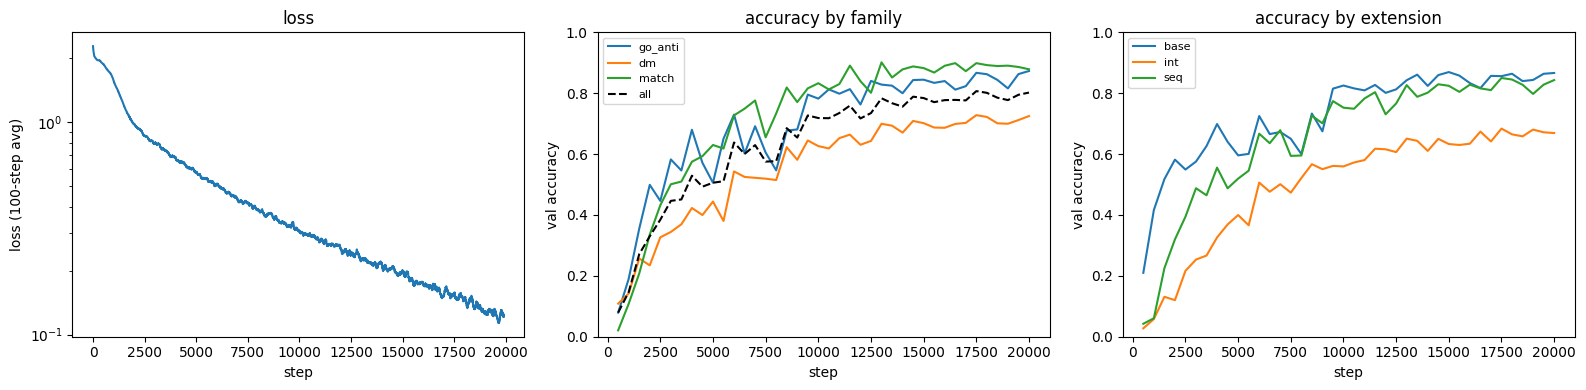

In [10]:
loss_np = loss_hist.cpu().numpy()
acc_np = torch.stack(acc_hist).cpu().numpy()

task_family = torch.stack([family[task_id == k][0] for k in range(n_tasks)]).cpu().numpy()
task_ext = torch.stack([extension[task_id == k][0] for k in range(n_tasks)]).cpu().numpy()
final = acc_np[-1]

w = min(100, max(1, len(loss_np) // 20))
kernel = np.ones(w) / w
smooth = lambda y: np.convolve(y, kernel, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(smooth(loss_np))
axes[0].set_yscale("log")
axes[0].set(xlabel="step", ylabel=f"loss ({w}-step avg)", title="loss")

for f, name in enumerate(family_names):
    axes[1].plot(eval_steps, acc_np[:, task_family == f].mean(axis=1), label=name)
axes[1].plot(eval_steps, acc_np.mean(axis=1), "k--", label="all")
axes[1].set(xlabel="step", ylabel="val accuracy", ylim=(0, 1), title="accuracy by family")
axes[1].legend(fontsize=8)

for e, name in enumerate(extension_names):
    axes[2].plot(eval_steps, acc_np[:, task_ext == e].mean(axis=1), label=name)
axes[2].set(xlabel="step", ylabel="val accuracy", ylim=(0, 1), title="accuracy by extension")
axes[2].legend(fontsize=8)
plt.tight_layout()

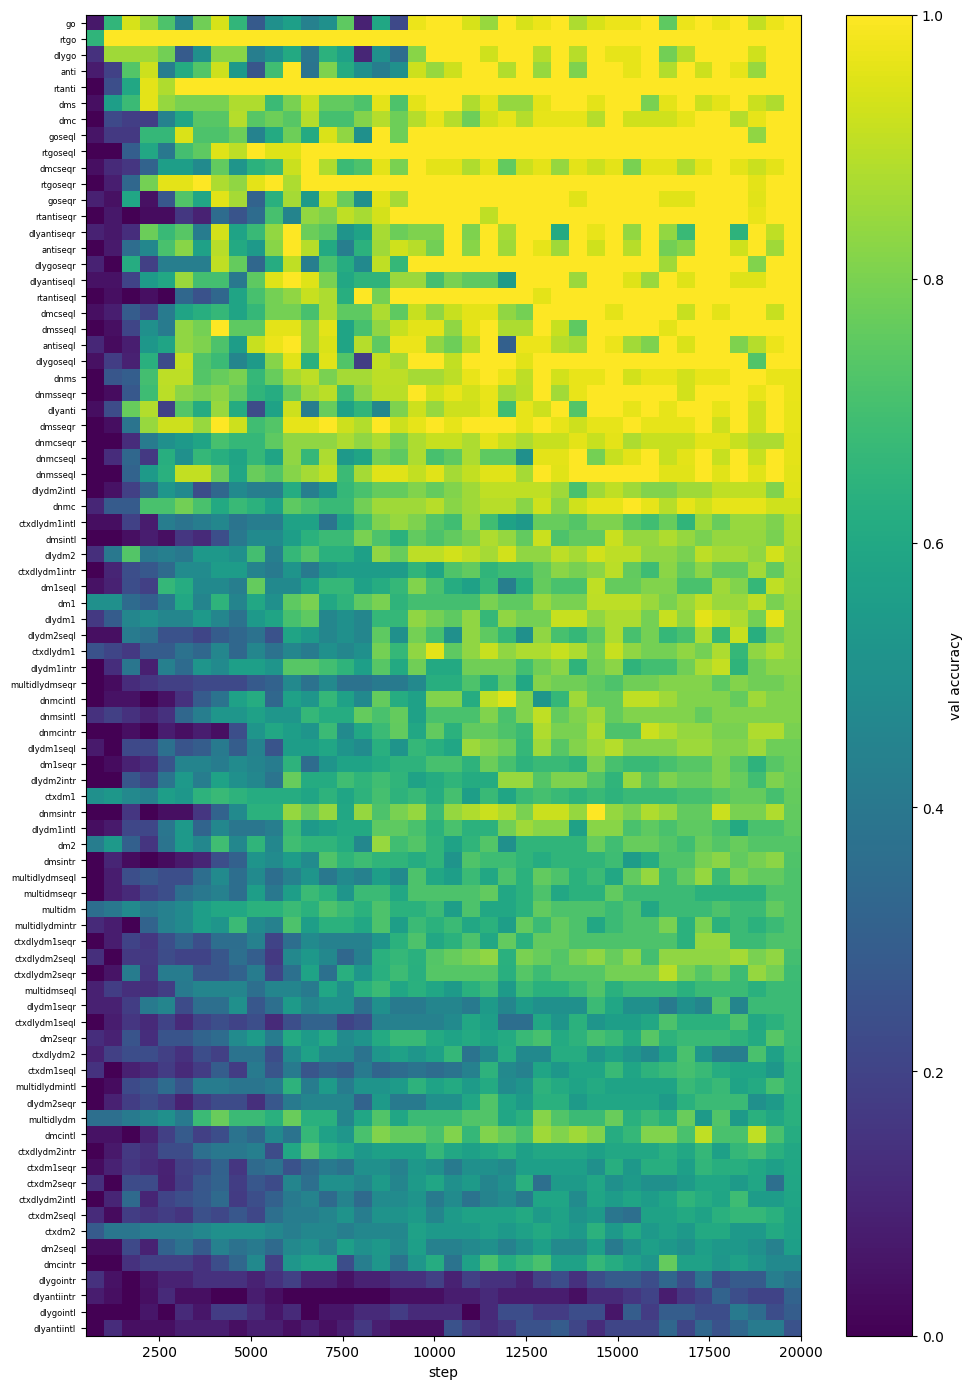

worst tasks: [('ctxdm2seqr', 0.591), ('ctxdlydm2intl', 0.586), ('ctxdm2seql', 0.576), ('ctxdm2', 0.571), ('dm2seql', 0.562), ('dmcintr', 0.476), ('dlygointr', 0.381), ('dlyantiintr', 0.32), ('dlygointl', 0.294), ('dlyantiintl', 0.25)]
mean acc 0.802 


In [11]:
order = np.argsort(-final)

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(acc_np[:, order].T, aspect="auto", vmin=0, vmax=1, cmap="viridis",
               extent=[eval_steps[0], eval_steps[-1], n_tasks - 0.5, -0.5])
ax.set_yticks(range(n_tasks))
ax.set_yticklabels([task_names[k] for k in order], fontsize=6)
ax.set_xlabel("step")
fig.colorbar(im, ax=ax, label="val accuracy")
plt.tight_layout()
plt.savefig("bah.png")
plt.show()

print("worst tasks:", [(task_names[k], round(float(final[k]), 3)) for k in order[-10:]])
print(f"mean acc {final.mean():.3f} ")

# PCA

In [13]:
hidden, lens, task = probe_hidden()
valid = torch.arange(t_max, device=DEVICE)[None] < lens[:, None]
unit = hidden / hidden.norm(dim=-1, keepdim=True).clamp_min(1e-8)

lab = labels[probe_idx]
resp = lab > 0
step_angle = (lab - 1).float() * 2 * torch.pi / bank["n_ring"]

# fit the direction plane on response steps: h -> (cos theta, sin theta)
h_resp = unit[resp]
ang_resp = step_angle[resp]
target = torch.stack([torch.cos(ang_resp), torch.sin(ang_resp)], dim=1)
w = torch.linalg.lstsq(h_resp, target).solution          # (n_hidden, 2)
q, _ = torch.linalg.qr(w)                                # orthonormal plane

fit = h_resp @ w
r2 = 1 - ((target - fit) ** 2).sum() / ((target - target.mean(0)) ** 2).sum()
proj = (unit @ q).cpu().numpy()                          # (P, T, 2)

print(f"R^2 {r2.item():.3f}")
for e, name in enumerate(extension_names):
    m = resp & (extension[probe_idx] == e)[:, None]
    f = unit[m] @ w
    t = torch.stack([torch.cos(step_angle[m]), torch.sin(step_angle[m])], dim=1)
    print(f"  {name}: R^2 {1 - ((t - f) ** 2).sum() / ((t - t.mean(0)) ** 2).sum():.3f}")

R^2 0.830
  base: R^2 0.895
  int: R^2 0.798
  seq: R^2 0.824


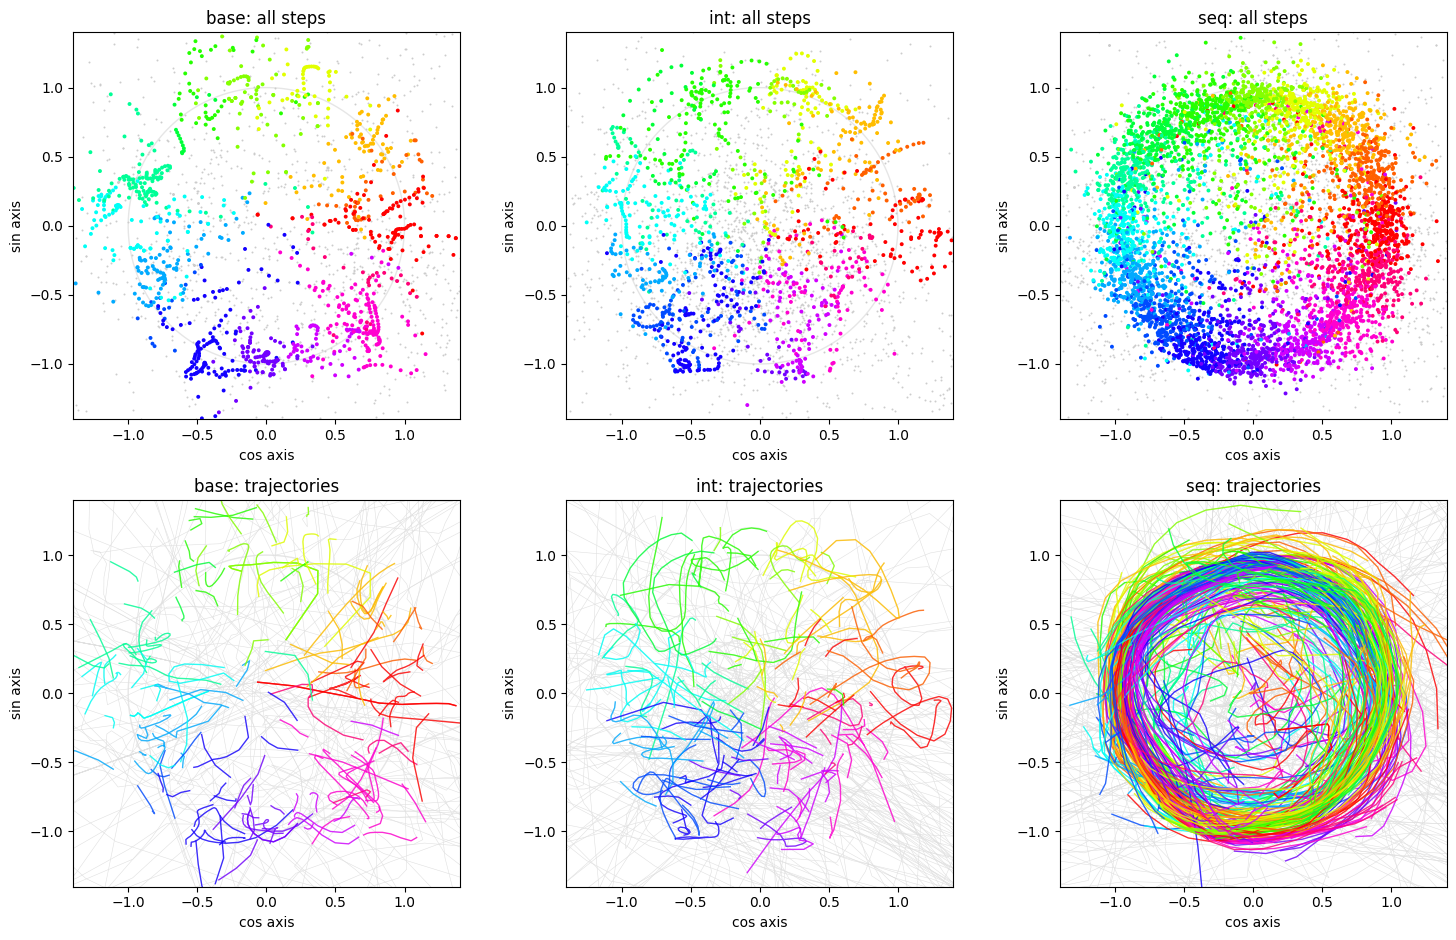

In [14]:
decoded = (unit @ w).cpu().numpy()          # (P, T, 2) — predicted (cos, sin)

step_colors = plt.cm.hsv((step_angle / (2 * torch.pi)).clamp(0, 1).cpu().numpy())
probe_ext = extension[probe_idx].cpu().numpy()
lens_np = lens.cpu().numpy()
resp_np = resp.cpu().numpy()
valid_np = valid.cpu().numpy()

circle = np.exp(1j * np.linspace(0, 2 * np.pi, 200))
lim = 1.4

fig, axes = plt.subplots(2, len(extension_names), figsize=(5 * len(extension_names), 9.5))

for e, name in enumerate(extension_names):
    sel = np.flatnonzero(probe_ext == e)

    for row in (0, 1):
        ax = axes[row, e]
        ax.plot(circle.real, circle.imag, color="0.9", lw=1, zorder=0)
        ax.set(xlabel="cos axis", ylabel="sin axis", xlim=(-lim, lim), ylim=(-lim, lim))
        ax.set_aspect("equal")

    ax = axes[0, e]
    for p in sel:
        m = valid_np[p] & ~resp_np[p]
        ax.scatter(decoded[p, m, 0], decoded[p, m, 1], c="0.8", s=2, linewidths=0)
    for p in sel:
        m = resp_np[p]
        ax.scatter(decoded[p, m, 0], decoded[p, m, 1], c=step_colors[p][m], s=8, linewidths=0)
    ax.set_title(f"{name}: all steps")

    ax = axes[1, e]
    for p in sel:
        n = lens_np[p]
        ax.plot(decoded[p, :n, 0], decoded[p, :n, 1], color="0.88", lw=0.4, zorder=0)
        m = resp_np[p]
        if m.any():
            ax.plot(decoded[p, m, 0], decoded[p, m, 1],
                    color=step_colors[p][m][0], lw=1.0, alpha=0.8)
    ax.set_title(f"{name}: trajectories")
plt.tight_layout()

## Save

In [15]:
torch.save(
    {
        "model": model.state_dict(),
        "config": {
            "n_in": n_in, "n_hidden": N_HIDDEN, "n_out": n_out, "alpha": alpha,
            "sigma_rec": SIGMA_REC, "activation": ACTIVATION,
        },
        "val_idx": val_idx.cpu(),
        "probe_idx": probe_idx.cpu(),
        "loss_hist": loss_hist.cpu(),
        "acc_hist": torch.stack(acc_hist).cpu(),
        "eval_steps": eval_steps,
    },
    CKPT_PATH,
)
print("saved", CKPT_PATH)

saved modcog_rnn.pt
